In [1]:
%load_ext dotenv
%dotenv
%load_ext mypy_ipython

In [2]:
from langgraph.graph import START, END, StateGraph,add_messages,MessagesState
from typing_extensions import TypedDict
from langchain_openai.chat_models import ChatOpenAI
from langchain_core.messages import HumanMessage, BaseMessage ,AIMessage
from collections.abc import Sequence
from typing import Literal ,Annotated

In [3]:
chat = ChatOpenAI(
    model = 'gpt-4o',
    seed = 365,
    temperature = 0.9,
    max_tokens=500
)

In [4]:
my_list = add_messages(
    [
        HumanMessage(content=f"Hey i'm Akhil"),
        AIMessage(content=f"Hey Akhil How Can i Help you today ?"),
    ],[
        HumanMessage(content=f"Hey summerize the News in India Today ?"),
    ]
)
print(my_list)

[HumanMessage(content="Hey i'm Akhil", additional_kwargs={}, response_metadata={}, id='6ac6f275-b3e5-422a-bd0e-8b02eab5cf26'), AIMessage(content='Hey Akhil How Can i Help you today ?', additional_kwargs={}, response_metadata={}, id='806cc593-a2a0-414e-a255-9d206222e9a9', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Hey summerize the News in India Today ?', additional_kwargs={}, response_metadata={}, id='71562870-6052-495b-9df5-4e842038c50d')]


In [5]:
#class State(TypedDict):
#   message: Annotated[Sequence[BaseMessage] , add_messages]

##
# No Longer State need to Managaed Manually we can do using MessagesState from Lanchain
# #

In [6]:
def ask_question(state : MessagesState) -> MessagesState:
    print(f'\n---------------ask_question Started')
    print('What is your Question?')
    for i in state['messages']:
        i.pretty_print()

    question = 'What is your Question?'
    print(question)

    return  MessagesState(
        messages = [AIMessage(content=question),HumanMessage(content=input())]
    )

In [7]:
#ask_question(MessagesState(messages=[]))

In [8]:
def chat_bot(state : MessagesState) -> MessagesState:
    print(f'\n---------------chat_bot Started')
    response = chat.invoke(
        state['messages']
    )

    for i in state['messages']:
        i.pretty_print()

    response.pretty_print()
    return MessagesState(
        messages = [response]
    )

In [9]:
def ask_another_question(state: MessagesState) -> MessagesState:
    print(f"\n-------> ENTERING ask_another_question:")
    question = "Would you like to ask one more question (yes/no)?"
    for i in state['messages']:
        i.pretty_print()
    print(question)

    return MessagesState(
        messages = [AIMessage(content=question),HumanMessage(content=input())]
    )

In [10]:
#ask_another_question(MessagesState(messages=[]))

In [11]:
def route_function(state: MessagesState) -> Literal['ask_question', END]:
    # -1 Brings the last Value
    if state['messages'][-1].content.lower() == 'yes':
        return 'ask_question'
    return END

##Build Graph

In [12]:
graph = StateGraph(MessagesState)

In [13]:
graph.add_node("ask_question", ask_question)
graph.add_node("chat_bot", chat_bot)
graph.add_node("ask_another_question", ask_another_question)

In [14]:
graph.add_edge(START,'ask_question')
graph.add_edge('ask_question','chat_bot')
graph.add_edge('chat_bot','ask_another_question')
graph.add_conditional_edges(
    source='ask_another_question',
    path= route_function
)

In [15]:
graph_compiled = graph.compile()

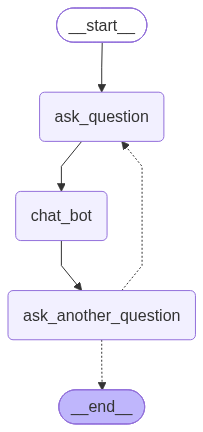

In [16]:
graph_compiled

In [17]:
graph_compiled.invoke(
    MessagesState(messages=[])
)


---------------ask_question Started
What is your Question?
What is your Question?


KeyboardInterrupt: Interrupted by user